# Stage 3 – Faiz Oranı Optimizasyonu

**Amaç:** Stage 2'den gelen risk skoru (0-1) kullanarak her başvuruya kişiselleştirilmiş faiz oranı hesapla.  
**Yöntem:** `configs/model_params.yaml` → `interest_optimization`

```
faiz_oranı = base_rate + risk_premium_max × f(risk_score)
base_rate = %5,  risk_premium_max = %15  →  Aralık: [%5, %20]
```

Pipeline'daki yeri:
```
Risk Skoru (Stage 2) → [Stage 3: Faiz Optimizasyonu] → Kişisel Faiz Oranı
```

## 1. Kütüphaneler ve Sabitler

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

ROOT = Path('..').resolve()
DATA_DIR   = ROOT / 'data' / 'processed'
MODEL_DIR  = ROOT / 'models'
FIG_DIR    = ROOT / 'reports' / 'figures'
METRIC_DIR = ROOT / 'reports' / 'metrics'
SRC_DIR    = ROOT / 'src' / 'pipeline'
CONFIG_PATH = ROOT / 'configs' / 'model_params.yaml'

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

ir_cfg = cfg['interest_optimization']
BASE_RATE        = ir_cfg['base_rate']         # 0.05
RISK_PREMIUM_MAX = ir_cfg['risk_premium_max']  # 0.15
METHOD           = ir_cfg['method']            # 'linear'

print(f'Base rate       : {BASE_RATE*100:.0f}%')
print(f'Risk premium max: {RISK_PREMIUM_MAX*100:.0f}%')
print(f'Yöntem          : {METHOD}')
print(f'Faiz aralığı    : {BASE_RATE*100:.0f}% – {(BASE_RATE+RISK_PREMIUM_MAX)*100:.0f}%')

Base rate       : 5%
Risk premium max: 15%
Yöntem          : linear
Faiz aralığı    : 5% – 20%


## 2. Faiz Eşleme Fonksiyonları

Üç yöntem karşılaştırılır: **linear**, **sigmoid**, **quadratic**.  
Üretimde `configs/model_params.yaml`'daki `method` anahtarı kullanılır.

In [2]:
def compute_interest_rate(risk_score: float | np.ndarray,
                          base_rate: float = BASE_RATE,
                          risk_premium_max: float = RISK_PREMIUM_MAX,
                          method: str = 'linear') -> float | np.ndarray:
    """
    Risk skorunu [0, 1] → faiz oranına [base_rate, base_rate + risk_premium_max] eşle.

    Parametreler
    ------------
    risk_score       : 0.0 (düşük risk) – 1.0 (yüksek risk)
    base_rate        : Minimum faiz oranı (ör. 0.05 = %5)
    risk_premium_max : Maksimum ek prim  (ör. 0.15 = %15)
    method           : 'linear' | 'sigmoid' | 'quadratic'

    Döndürür
    --------
    Faiz oranı (0.0 – 1.0 formatında, ör. 0.12 = %12)
    """
    s = np.clip(risk_score, 0.0, 1.0)

    if method == 'linear':
        premium = s
    elif method == 'sigmoid':
        # Sigmoid: düşük risk için prim yavaş artar, yüksek riskte hızlanır
        premium = 1 / (1 + np.exp(-10 * (s - 0.5)))
    elif method == 'quadratic':
        # Kuadratik: yüksek risklileri daha sert cezalandırır
        premium = s ** 2
    else:
        raise ValueError(f"Bilinmeyen yöntem: {method}. 'linear' | 'sigmoid' | 'quadratic'")

    return base_rate + risk_premium_max * premium


# Örnek kontrol
for score in [0.0, 0.25, 0.5, 0.6491, 0.75, 1.0]:
    rate = compute_interest_rate(score, method=METHOD)
    print(f'  Risk={score:.4f} → Faiz={rate*100:.2f}%')

  Risk=0.0000 → Faiz=5.00%
  Risk=0.2500 → Faiz=8.75%
  Risk=0.5000 → Faiz=12.50%
  Risk=0.6491 → Faiz=14.74%
  Risk=0.7500 → Faiz=16.25%
  Risk=1.0000 → Faiz=20.00%


## 3. Yöntem Karşılaştırması

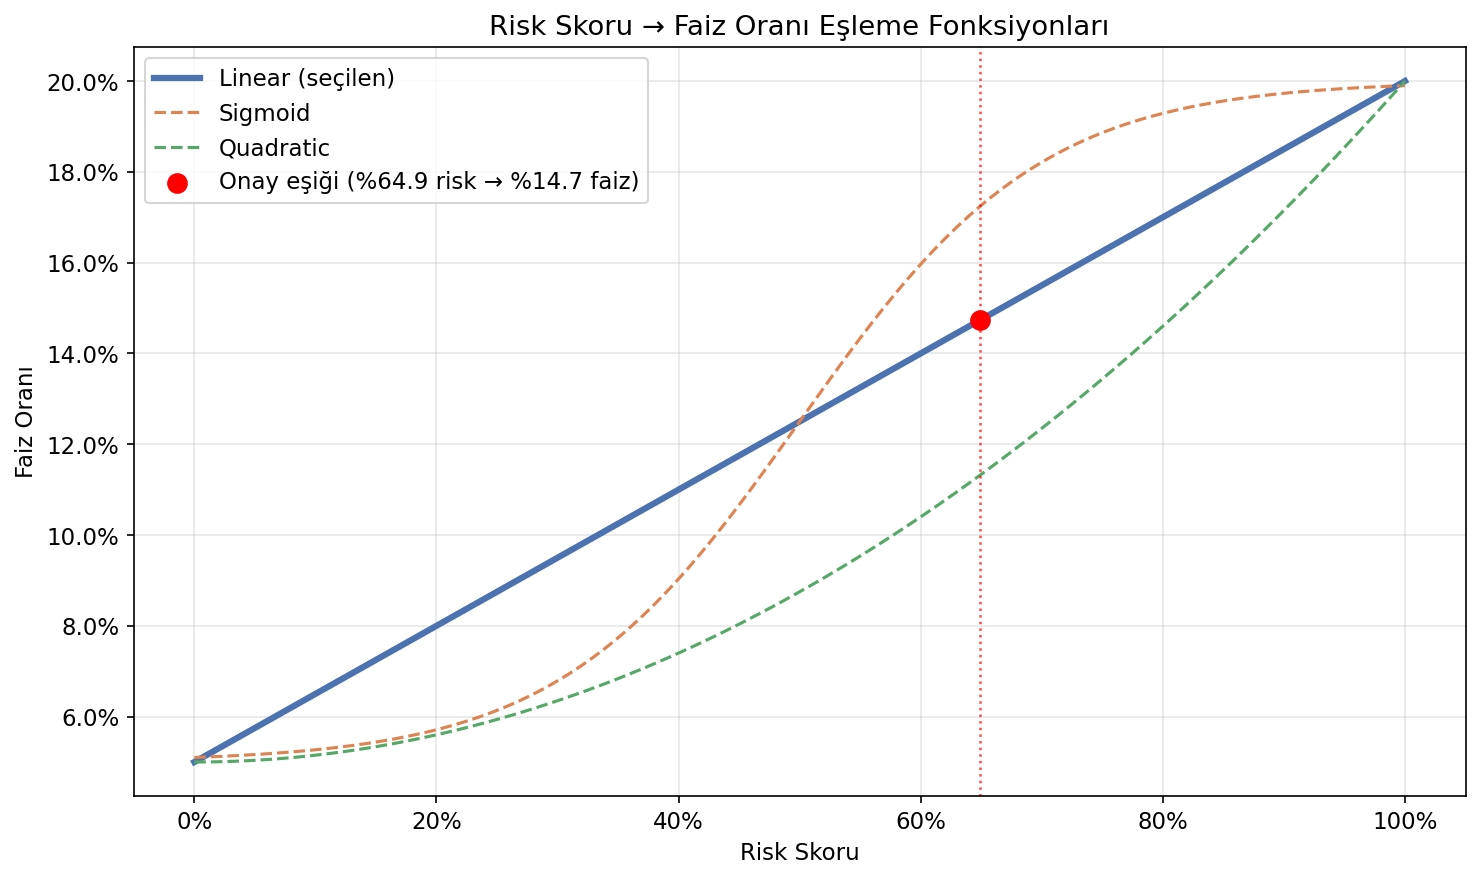

Kaydedildi: ir_01_rate_curve.png


In [3]:
scores = np.linspace(0, 1, 300)
methods = ['linear', 'sigmoid', 'quadratic']
colors  = ['#4C72B0', '#DD8452', '#55A868']
labels  = ['Linear (seçilen)', 'Sigmoid', 'Quadratic']

fig, ax = plt.subplots(figsize=(10, 6))

for method, color, label in zip(methods, colors, labels):
    rates = compute_interest_rate(scores, method=method) * 100
    lw = 3 if method == METHOD else 1.5
    ls = '-' if method == METHOD else '--'
    ax.plot(scores * 100, rates, color=color, linewidth=lw, linestyle=ls, label=label)

# Optimal threshold işareti
opt_threshold = 0.6491
opt_rate = compute_interest_rate(opt_threshold, method=METHOD) * 100
ax.axvline(opt_threshold * 100, color='red', linestyle=':', linewidth=1.2, alpha=0.7)
ax.scatter([opt_threshold * 100], [opt_rate], color='red', s=80, zorder=5,
           label=f'Onay eşiği (%{opt_threshold*100:.1f} risk → %{opt_rate:.1f} faiz)')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Risk Skoru')
ax.set_ylabel('Faiz Oranı')
ax.set_title('Risk Skoru → Faiz Oranı Eşleme Fonksiyonları')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ir_01_rate_curve.png')
plt.show()
print('Kaydedildi: ir_01_rate_curve.png')

## 4. Risk Bantlarına Göre Faiz Dağılımı

In [4]:
# Risk bantları
risk_bands = [
    ('Çok Düşük',  0.00, 0.20, '#2ca02c'),
    ('Düşük',      0.20, 0.40, '#98df8a'),
    ('Orta',       0.40, 0.55, '#ffbb78'),
    ('Yüksek',     0.55, 0.70, '#ff7f0e'),
    ('Çok Yüksek', 0.70, 1.00, '#d62728'),
]

rows = []
for name, lo, hi, _ in risk_bands:
    mid   = (lo + hi) / 2
    rate  = compute_interest_rate(mid, method=METHOD)
    lo_r  = compute_interest_rate(lo,  method=METHOD)
    hi_r  = compute_interest_rate(hi,  method=METHOD)
    rows.append({'Bant': name,
                 'Risk Aralığı': f'{lo*100:.0f}% – {hi*100:.0f}%',
                 'Orta Nokta Faiz': f'{rate*100:.1f}%',
                 'Faiz Aralığı': f'{lo_r*100:.1f}% – {hi_r*100:.1f}%'})

band_df = pd.DataFrame(rows)
print(band_df.to_string(index=False))

      Bant Risk Aralığı Orta Nokta Faiz  Faiz Aralığı
 Çok Düşük     0% – 20%            6.5%   5.0% – 8.0%
     Düşük    20% – 40%            9.5%  8.0% – 11.0%
      Orta    40% – 55%           12.1% 11.0% – 13.2%
    Yüksek    55% – 70%           14.4% 13.2% – 15.5%
Çok Yüksek   70% – 100%           17.8% 15.5% – 20.0%


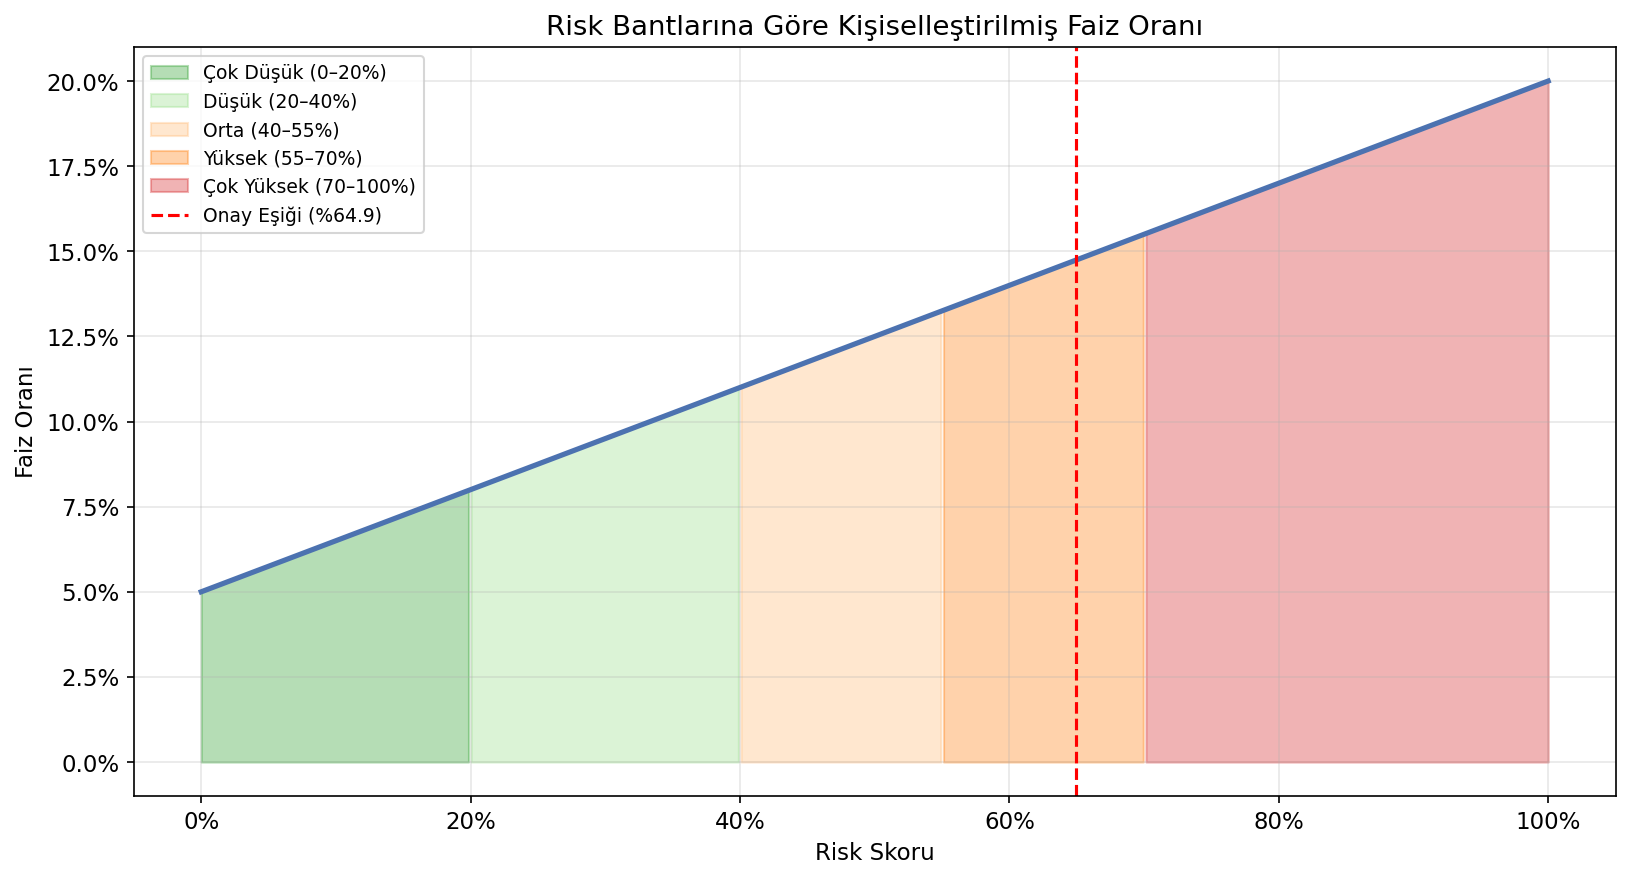

Kaydedildi: ir_02_risk_band_rates.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
scores_plot = np.linspace(0, 1, 500)
rates_plot  = compute_interest_rate(scores_plot, method=METHOD) * 100

# Her bant için renklendirme
for name, lo, hi, color in risk_bands:
    mask = (scores_plot >= lo) & (scores_plot <= hi)
    ax.fill_between(scores_plot[mask] * 100, rates_plot[mask],
                    alpha=0.35, color=color, label=f'{name} ({lo*100:.0f}–{hi*100:.0f}%)')

ax.plot(scores_plot * 100, rates_plot, color='#4C72B0', linewidth=2.5)
ax.axvline(opt_threshold * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'Onay Eşiği (%{opt_threshold*100:.1f})')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Risk Skoru')
ax.set_ylabel('Faiz Oranı')
ax.set_title('Risk Bantlarına Göre Kişiselleştirilmiş Faiz Oranı')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ir_02_risk_band_rates.png')
plt.show()
print('Kaydedildi: ir_02_risk_band_rates.png')

## 5. Gerçek Veri Üzerinde Dağılım

In [6]:
# XGBoost ile test setindeki risk skorlarını üret
xgb_model = joblib.load(MODEL_DIR / 'xgboost_risk_model.joblib')
X_test  = pd.read_csv(DATA_DIR / 'X_test.csv')
y_test  = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze()

risk_scores = xgb_model.predict_proba(X_test)[:, 1]
interest_rates = compute_interest_rate(risk_scores, method=METHOD) * 100

print(f'Risk skoru istatistikleri:')
print(pd.Series(risk_scores).describe().round(4))
print(f'\nFaiz oranı istatistikleri (%):')
print(pd.Series(interest_rates).describe().round(2))

Risk skoru istatistikleri:
count    51070.0000
mean         0.4239
std          0.2041
min          0.0269
25%          0.2596
50%          0.4029
75%          0.5757
max          0.9691
dtype: float64

Faiz oranı istatistikleri (%):
count    51070.00
mean        11.36
std          3.06
min          5.40
25%          8.89
50%         11.04
75%         13.64
max         19.54
dtype: float64


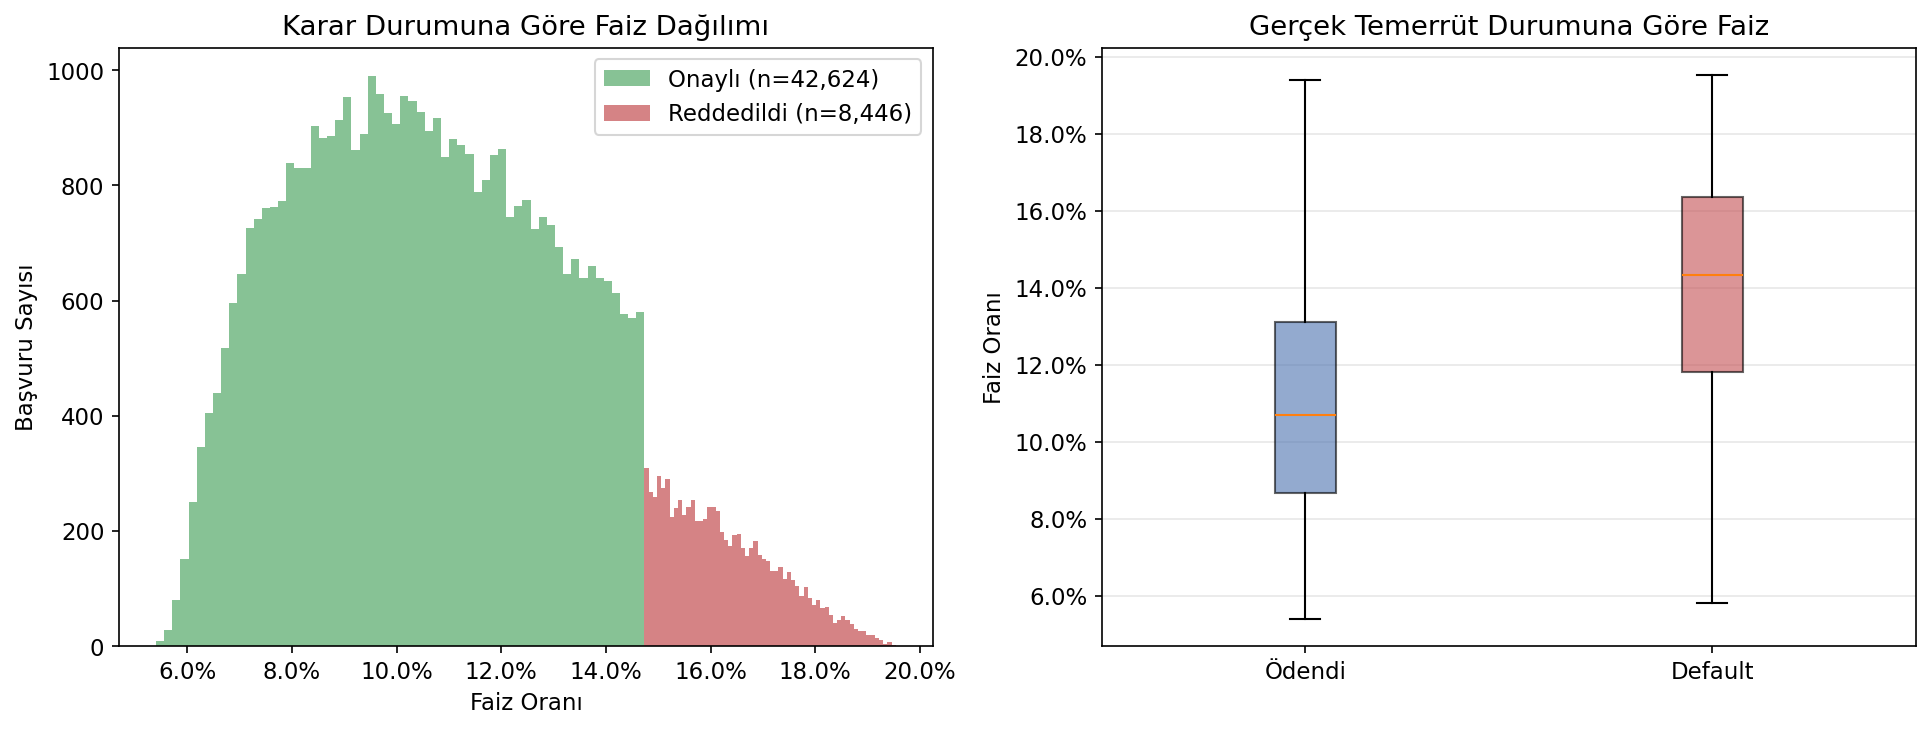

Kaydedildi: ir_03_actual_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sol: Onaylanan vs reddedilen için faiz dağılımı
opt_thresh = 0.6491
approved = risk_scores < opt_thresh  # düşük risk = onaylı
axes[0].hist(interest_rates[approved],  bins=60, alpha=0.7, color='#55A868', label=f'Onaylı (n={approved.sum():,})')
axes[0].hist(interest_rates[~approved], bins=60, alpha=0.7, color='#C44E52', label=f'Reddedildi (n={(~approved).sum():,})')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_xlabel('Faiz Oranı')
axes[0].set_ylabel('Başvuru Sayısı')
axes[0].set_title('Karar Durumuna Göre Faiz Dağılımı')
axes[0].legend()

# Sağ: Gerçek temerrüt durumuna göre faiz kutusu
df_plot = pd.DataFrame({'interest_rate': interest_rates, 'default': y_test.values})
groups = [df_plot.loc[df_plot['default'] == 0, 'interest_rate'],
          df_plot.loc[df_plot['default'] == 1, 'interest_rate']]
bp = axes[1].boxplot(groups, labels=['Ödendi', 'Default'],
                     patch_artist=True,
                     boxprops={'facecolor': '#4C72B0', 'alpha': 0.6})
bp['boxes'][1].set_facecolor('#C44E52')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylabel('Faiz Oranı')
axes[1].set_title('Gerçek Temerrüt Durumuna Göre Faiz')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'ir_03_actual_distribution.png')
plt.show()
print('Kaydedildi: ir_03_actual_distribution.png')

## 6. Örnek Profiller

Pipeline çıktısının nasıl görüneceğini somutlaştırmak için 5 farklı profil.

In [8]:
profiles = [
    {'isim': 'Düşük Riskli Ahmet',   'risk_score': 0.08},
    {'isim': 'Orta Riskli Ayşe',     'risk_score': 0.35},
    {'isim': 'Sınırda Mehmet',        'risk_score': 0.55},
    {'isim': 'Yüksek Riskli Fatma',  'risk_score': 0.75},
    {'isim': 'Çok Riskli Kemal',     'risk_score': 0.92},
]

print(f'{"İsim":<25} {"Risk Skoru":>12} {"Faiz Oranı":>12} {"Karar":>12}')
print('-' * 65)
for p in profiles:
    rate    = compute_interest_rate(p['risk_score'], method=METHOD)
    karar   = 'ONAYLI' if p['risk_score'] < opt_thresh else 'REDDEDİLDİ'
    print(f"{p['isim']:<25} {p['risk_score']:>11.4f} {rate*100:>10.1f}% {karar:>12}")

İsim                        Risk Skoru   Faiz Oranı        Karar
-----------------------------------------------------------------
Düşük Riskli Ahmet             0.0800        6.2%       ONAYLI
Orta Riskli Ayşe               0.3500       10.2%       ONAYLI
Sınırda Mehmet                 0.5500       13.2%       ONAYLI
Yüksek Riskli Fatma            0.7500       16.2%   REDDEDİLDİ
Çok Riskli Kemal               0.9200       18.8%   REDDEDİLDİ


## 7. Fonksiyonu Python Modülü Olarak Kaydet

In [9]:
interest_rate_module = '''"""
Faiz Oranı Optimizasyonu – Stage 3

Bu modül src/pipeline/interest_rate.py olarak kullanılmak üzere 
05_interest_rate_optimization.ipynb'den çıkarılmıştır.
"""
import numpy as np


def compute_interest_rate(
    risk_score: float,
    base_rate: float = 0.05,
    risk_premium_max: float = 0.15,
    method: str = "linear",
) -> float:
    """Risk skorunu faiz oranına çevirir.

    Args:
        risk_score: [0.0, 1.0] aralığında XGBoost tahmin olasılığı.
        base_rate: Minimum faiz oranı (varsayılan %5).
        risk_premium_max: Maksimum ek prim (varsayılan %15).
        method: 'linear' | 'sigmoid' | 'quadratic'

    Returns:
        Faiz oranı (ondalık, ör. 0.12 = %12).
    """
    s = float(np.clip(risk_score, 0.0, 1.0))

    if method == "linear":
        premium = s
    elif method == "sigmoid":
        premium = 1.0 / (1.0 + np.exp(-10.0 * (s - 0.5)))
    elif method == "quadratic":
        premium = s ** 2
    else:
        raise ValueError(f"Bilinmeyen yöntem: {method}")

    return base_rate + risk_premium_max * premium
'''

SRC_DIR.mkdir(parents=True, exist_ok=True)
module_path = SRC_DIR / 'interest_rate.py'
module_path.write_text(interest_rate_module, encoding='utf-8')
print(f'Modül kaydedildi: {module_path}')

Modül kaydedildi: C:\Users\nesli\Desktop\LoanGuard\src\pipeline\interest_rate.py


In [10]:
from datetime import datetime

# Metadata JSON
metadata = {
    "model_version"     : "1.0.0",
    "created_at"        : datetime.now().isoformat(),
    "base_rate"         : BASE_RATE,
    "risk_premium_max"  : RISK_PREMIUM_MAX,
    "max_rate"          : BASE_RATE + RISK_PREMIUM_MAX,
    "method"            : METHOD,
    "optimal_threshold" : 0.6491304347826087,
    "risk_bands"        : [
        {"name": name, "low": lo, "high": hi}
        for name, lo, hi, _ in risk_bands
    ],
}

meta_path = MODEL_DIR / "interest_rate_metadata.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)
print("Metadata kaydedildi:", meta_path)

# Metrics JSON
opt_thresh    = 0.6491
approved_mask = risk_scores < opt_thresh

metrics = {
    "generated_at"  : datetime.now().isoformat(),
    "test_samples"  : int(len(risk_scores)),
    "approval_rate" : round(float(approved_mask.mean()), 6),
    "rejection_rate": round(float((~approved_mask).mean()), 6),
    "interest_rate_stats": {
        "mean": round(float(interest_rates.mean()), 4),
        "std" : round(float(interest_rates.std()),  4),
        "min" : round(float(interest_rates.min()),  4),
        "max" : round(float(interest_rates.max()),  4),
    },
    "approved": {
        "count"    : int(approved_mask.sum()),
        "mean_rate": round(float(interest_rates[approved_mask].mean()), 4),
    },
    "rejected": {
        "count"    : int((~approved_mask).sum()),
        "mean_rate": round(float(interest_rates[~approved_mask].mean()), 4),
    },
}

metrics_path = METRIC_DIR / "interest_rate_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)
print("Metrikler kaydedildi:", metrics_path)

Metadata kaydedildi: C:\Users\nesli\Desktop\LoanGuard\models\interest_rate_metadata.json
Metrikler kaydedildi: C:\Users\nesli\Desktop\LoanGuard\reports\metrics\interest_rate_metrics.json


## 8. Özet

| Çıktı | Yer |
|---|---|
| `ir_01_rate_curve.png` | `reports/figures/` |
| `ir_02_risk_band_rates.png` | `reports/figures/` |
| `ir_03_actual_distribution.png` | `reports/figures/` |
| `interest_rate.py` | `src/pipeline/` |
| `interest_rate_metadata.json` | `models/` |
| `interest_rate_metrics.json` | `reports/metrics/` |
| `interest_rate.joblib` | `models/` |

**Faiz aralığı:** %5 (sıfır risk) – %20 (tam risk)  
**Seçilen yöntem:** `linear` (basit ve yorumlanabilir)  
**Onay eşiğinde faiz:** %14.7  

**Sonraki adım:** `src/models/predictor.py` – 3 aşamayı tek sınıfta birleştir
